# Real-Time Fraud Detection

**Research question:** Can we build a real-time machine learning system that accurately identifies fraudulent transactions while minimising financial loss from false decisions under extreme class imbalance?

In [1]:
import sys
print(sys.executable)

/Users/anshikabhanot/miniconda3/envs/fraud-env/bin/python


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from fraud_detection.config import RAW_DATA_PATH, TARGET_COLUMN
from fraud_detection.data import load_creditcard_data, split_features_target, stratified_train_test_split
from fraud_detection.train import build_models
from fraud_detection.evaluation import classification_metrics, select_min_cost_threshold, threshold_cost_curve

sns.set_theme(style='whitegrid')

## 1. Load Data

In [3]:
data = load_creditcard_data(RAW_DATA_PATH)
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Class Imbalance

,count,rate
Class,,
legitimate,284315,0.998273
fraud,492,0.001727


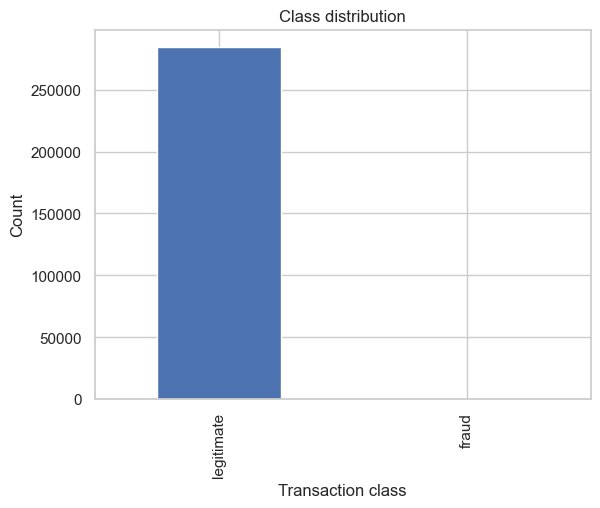

In [4]:
class_counts = data[TARGET_COLUMN].value_counts().rename(index={0: 'legitimate', 1: 'fraud'})
class_rate = data[TARGET_COLUMN].value_counts(normalize=True).rename(index={0: 'legitimate', 1: 'fraud'})
display(pd.concat([class_counts.rename('count'), class_rate.rename('rate')], axis=1))

ax = class_counts.plot(kind='bar', title='Class distribution')
ax.set_xlabel('Transaction class')
ax.set_ylabel('Count');

## 3. EDA

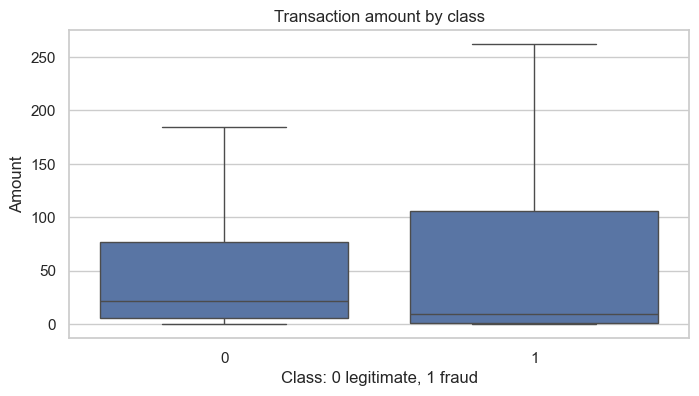

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=data, x=TARGET_COLUMN, y='Amount', showfliers=False, ax=ax)
ax.set_title('Transaction amount by class')
ax.set_xlabel('Class: 0 legitimate, 1 fraud');

## 4. Train/Test Split

In [6]:
X, y = split_features_target(data)
X_train, X_test, y_train, y_test = stratified_train_test_split(X, y)
X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((227845, 30),
 (56962, 30),
 np.float64(0.001729245759178389),
 np.float64(0.0017204452090867595))

## 5. Model Comparison

In [7]:
models = build_models(y_train)
rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    curve = threshold_cost_curve(y_test, y_proba, false_positive_cost=25, false_negative_cost=2500)
    threshold = select_min_cost_threshold(curve)['threshold']
    metrics = classification_metrics(y_test, y_proba, threshold)
    rows.append({
        'model': name,
        'threshold': threshold,
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'pr_auc': metrics['pr_auc'],
        'roc_auc': metrics['roc_auc'],
        'false_positives': metrics['false_positives'],
        'false_negatives': metrics['false_negatives'],
    })

pd.DataFrame(rows).sort_values('pr_auc', ascending=False)

,model,threshold,precision,recall,f1,pr_auc,roc_auc,false_positives,false_negatives
2,xgboost,0.39,0.630435,0.887755,0.737288,0.865466,0.983439,51,11
1,random_forest,0.04,0.598639,0.897959,0.718367,0.861136,0.951760,59,10
0,logistic_regression,0.97,0.478022,0.887755,0.621429,0.718971,0.972083,95,11


## 6. Cost-Sensitive Threshold Tuning

threshold              0.39
false_positives       51.00
false_negatives       11.00
true_positives        87.00
true_negatives     56813.00
total_cost         28775.00
Name: 38, dtype: float64

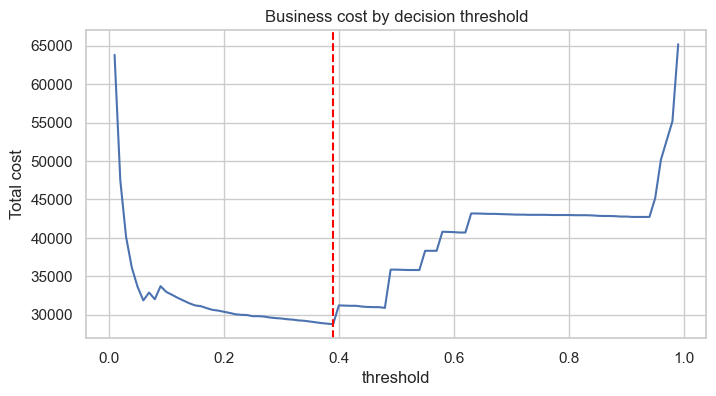

In [8]:
best_model = models['xgboost']
y_proba = best_model.predict_proba(X_test)[:, 1]
curve = pd.DataFrame(threshold_cost_curve(y_test, y_proba, false_positive_cost=25, false_negative_cost=2500))
best = curve.loc[curve['total_cost'].idxmin()]
display(best)

ax = curve.plot(x='threshold', y='total_cost', figsize=(8, 4), legend=False)
ax.axvline(best['threshold'], color='red', linestyle='--')
ax.set_title('Business cost by decision threshold')
ax.set_ylabel('Total cost');